# **XPM Scanning Approach**

The coupled NLS Equations of two co-propagating pulses are given by:
$$
\frac{\partial A_1}{\partial z} + \frac{1}{v_{g1}} \frac{\partial A_1}{\partial t} + \frac{i\beta_{21}}{2} \frac{\partial^2 A_1}{\partial t^2} + \frac{\alpha_1}{2} A_1 = i\gamma_1 (|A_1|^2 + 2 f_{12}|A_2|^2) A_1,
\\
\frac{\partial A_2}{\partial z} + \frac{1}{v_{g2}} \frac{\partial A_2}{\partial t} + \frac{i\beta_{22}}{2} \frac{\partial^2 A_2}{\partial t^2} + \frac{\alpha_2}{2} A_2 = i\gamma_2 (|A_2|^2 + 2 f_{21}|A_1|^2) A_2,
$$
where $\beta_{21}$ and $\beta_{22}$, as well as $\gamma_1$ and $\gamma_2$ are different for different media and depend on the mode (frequency) of light and where $f_{jk}$ is the overlap integral (a scalar value dependent on the mode and nature of the two propagating waves). Neglecting loss terms $\alpha = 0$ and assuming overlap $f_{jk} = 1$:
$$
\frac{\partial A_1}{\partial z} 
= - i\frac{\beta_{21}}{2} \frac{\partial^2 A_1}{\partial T^2} + i\gamma_1|A_1|^2A_1 + 2i\gamma_1|A_2|^2A_1, \\[6pt] = \bigl[ \mathscr{L} + \mathscr{N}_1 + \mathscr{N}_2 \bigr] A_1
$$
$$
\frac{\partial A_2}{\partial z}  
= - d \frac{\partial A_2}{\partial T} -
i\frac{\beta_{22}}{2} \frac{\partial^2 A_2}{\partial T^2} + i\gamma_2|A_2|^2A_2 + 2i\gamma_2  |A_1|^2 A_2 = \bigl[ \mathscr{L}_1 + \mathscr{L}_2 + \mathscr{N}_2 + \mathscr{N}_1 \bigr] A_2
$$

where $T = t - \frac{z}{v_{g1}}$ and $d = \frac{v_{g1} - v_{g2}}{v_{g1} v_{g2}}$. 

Thus **the numerical solution to the XPM wave-propagation** for the wave $j$ interacting with wave $k$ is
$$
    A(z + \Delta z, T) = \mathcal{F}^{-1}\left\{ e^{i\frac{\beta_2j}{2} \omega^2 \Delta z}  \cdot   \mathcal{F} \left\{   e^{i \gamma (|A_j(z, T)|^2 + 2|A_k(z,T)|^2) \Delta z} A_j(z, T) \right\}  \right\} 
$$
or, using Strang splitting:
$$
A_j(z + \Delta z, T) 
= 
e^{\,i \gamma \bigl(|A_j(z, T)|^2 + 2|A_k(z, T)|^2\bigr) \frac{\Delta z}{2}}
\,\mathcal{F}^{-1}
\!\left\{
   e^{\,i\frac{\beta_{2j}}{2} \omega^2 \Delta z}
   \,\mathcal{F}\!\left[
      e^{\,i \gamma \bigl(|A_j(z, T)|^2 + 2|A_k(z, T)|^2\bigr) \frac{\Delta z}{2}}
      A_j(z, T)
   \right]
\right\}.
$$

Thus **the numerical solution to the XPM wave-propagation** is:

_Pulse $1$:_
$$
A_1(z + \Delta z, T) = 
\mathcal{F}^{-1}\left\{
   e^{\,i\frac{\beta_{21}}{2}\omega^2 \Delta z}
   \,\mathcal{F}\left[
      e^{\,i\gamma_1\bigl(|A_1(z,T)|^2 + 2|A_2(z,T)|^2\bigr)\Delta z}
      \,A_1(z,T)
   \right]
\right\}.
$$
_Pulse $2$:_
$$
A_2(z + \Delta z, T) = 
\mathcal{F}^{-1}\left\{
   e^{\,i\bigl(\frac{\beta_{22}}{2}\omega^2 - d\omega\bigr)\Delta z}
   \,\mathcal{F}\left[
      e^{\,i\gamma_2\bigl(|A_2(z,T)|^2 + 2|A_1(z,T)|^2\bigr)\Delta z}
      \,A_2(z,T)
   \right]
\right\}.
$$

or with **Strang Splitting**
_Pulse $1$:_
$$
A_1(z + \Delta z, T) =
e^{\,i\gamma_1\bigl(|A_1(z,T)|^2 + 2|A_2(z,T)|^2\bigr)\frac{\Delta z}{2}}
\,\mathcal{F}^{-1}\left\{
   e^{\,i\frac{\beta_{21}}{2}\omega^2 \Delta z}
   \,\mathcal{F}\left[
      e^{\,i\gamma_1\bigl(|A_1(z,T)|^2 + 2|A_2(z,T)|^2\bigr)\frac{\Delta z}{2}}
      \,A_1(z,T)
   \right]
\right\}.
$$
_Pulse $2$:_
$$
A_2(z + \Delta z, T) =
e^{\,i\gamma_2\bigl(|A_2(z,T)|^2 + 2|A_1(z,T)|^2\bigr)\frac{\Delta z}{2}}
\,\mathcal{F}^{-1}\left\{
   e^{\,i\bigl(\frac{\beta_{22}}{2}\omega^2 - d\omega\bigr)\Delta z}
   \,\mathcal{F}\left[
      e^{\,i\gamma_2\bigl(|A_2(z,T)|^2 + 2|A_1(z,T)|^2\bigr)\frac{\Delta z}{2}}
      \,A_2(z,T)
   \right]
\right\}.
$$





In [1]:
# general imports
import numpy as np
import matplotlib.pyplot as plt
import os

# ml imports
import torch

# import module
from nlse import *

Using device: cpu


In [8]:
# define simulation parameters
Lz = 1e-2               # Propagation distance in km
Nz = 1000              # Number of steps in z
Lt = 14              # Temporal window size
Nt = 2048               # Number of temporal points
dz = Lz / Nz            
dt = Lt / Nt

# define medium parameters
beta2_j = -10.0           # Dispersion coefficient in ps^2/km
beta2_k = -10.0           # Dispersion coefficient in ps^2/km
gamma_j = 1.0
gamma_k = 1.0

delta_beta = 100.0          # Delta beta coefficient in ps/km

# define pulse parameters
tau1 = 0.1
tau2 = 0.8


print(f"Strong pulse travels {Lz * delta_beta} ps")

Strong pulse travels 1.0 ps


In [9]:
# independent variable (we use torch for automatic differentiation)
t = torch.linspace(-Lt/2, Lt/2, Nt) 


### Run Test Simulation

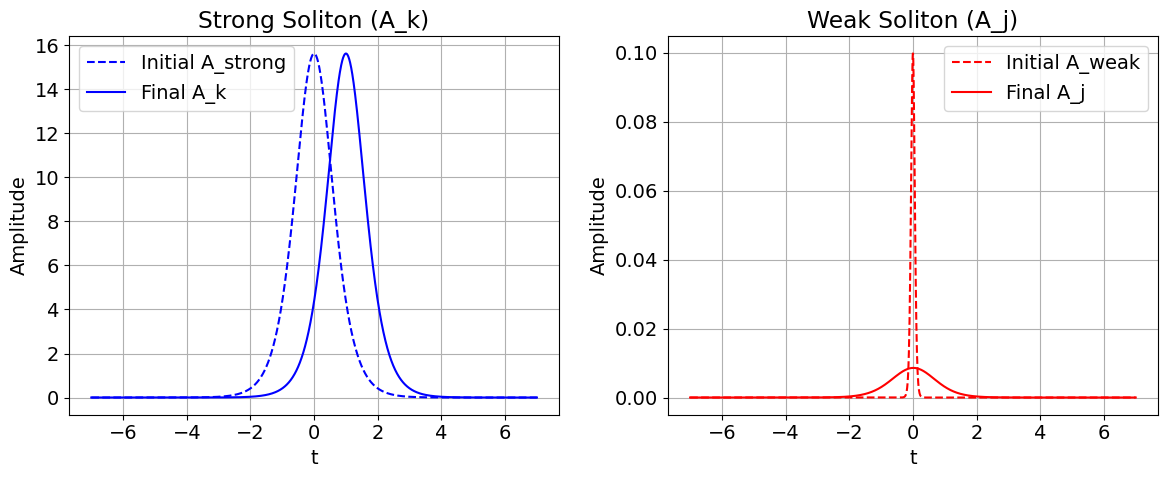

In [11]:
def strong_soliton(t, beta2_k, gamma_k, tau, offset=0.0):
    a_2_squared = -beta2_k / (gamma_k * tau**2)
    a_2 = np.sqrt(a_2_squared)
    # Shift the pulse to the left by tau (i.e., t -> t+tau)
    return a_2 * torch.cosh((t + offset) / tau)**(-1)

def weak_soliton(t, beta2_k, beta2_j, gamma_j, gamma_k, tau, amplitude_ratio=100.0):
    a_2_squared = -beta2_k / (gamma_k * tau**2)
    a_2 = np.sqrt(a_2_squared)
    a_1 = a_2 / amplitude_ratio
    p = 0.5 * (-1 + np.sqrt(1 + 16 * beta2_k * gamma_j / (beta2_j * gamma_k)))
    return a_1 * (torch.cosh(t / tau)**(-1))**p

A_weak = weak_soliton(t, beta2_k, beta2_j, gamma_j, gamma_k, tau1)
A_strong = strong_soliton(t, beta2_k, gamma_k, tau2, offset=0)

# Run Test Simulation
A_j_evolution, A_k_evolution = drift_split_step_fourier_xpm(A_weak, A_strong, dz, Nz, beta2_j, beta2_k, delta_beta, gamma_j, gamma_k, Lt)



fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot initial strong soliton (A_strong) with dashed line
axs[0].plot(t.cpu(), (torch.abs(A_strong)**2).cpu().numpy(), label="Initial A_strong", color='b', linestyle='--')
# Plot final A_k pulse after evolution
axs[0].plot(t.cpu(), (torch.abs(A_k_evolution[:, -1])**2).cpu().numpy(), label="Final A_k", color='b')
axs[0].set_title("Strong Soliton (A_k)")
axs[0].set_xlabel("t")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True)
axs[0].legend()

# Plot initial weak soliton (A_weak) with dashed line
axs[1].plot(t.cpu(), (torch.abs(A_weak)**2).cpu().numpy(), label="Initial A_weak", color='r', linestyle='--')
# Plot final A_j pulse after evolution
axs[1].plot(t.cpu(), (torch.abs(A_j_evolution[:, -1])**2).cpu().numpy(), label="Final A_j", color='r')
axs[1].set_title("Weak Soliton (A_j)")
axs[1].set_xlabel("t")
axs[1].set_ylabel("Amplitude")
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()


## **HG Basis Considerations**

### Pulse Width Selection


For the Hermite–Gaussian modes RMS width of the intensity is:

$$
\sigma_n = \sqrt{\langle t^2 \rangle_n},
\qquad
\langle t^2 \rangle_n = \int_{-\infty}^{\infty} t^2 I_n(t)\,dt.
$$


$$
\boxed{
\langle x^2 \rangle_n = \tau^2\left(n + \frac{1}{2}\right)
}
\quad\Rightarrow\quad
\boxed{
\sigma_n = \tau \sqrt{\,n + \tfrac{1}{2}\,}.
}
$$

This is a clean analytic measure of how “wide” the mode of order \(n\) is.

Conversely, for higher-order modes, the intensity has multiple peaks with the maxima being the outer peaks approximately at

$$
\boxed{
x_{\text{peak}} \approx \pm \tau \sqrt{2n + 1}.
}
$$


We want the width of a peak in the largest mode (call it $n$) of the strong pulse to be roughly the width of the $0$-th mode of the weak pulse. This is how we decide on the scaling relation between $\tau_1$ and $\tau_2$.
All width definitions scale the same. We define width of the $n$-th mode in terms of the RMS width as:
$$
w_{n, \tau} = \frac{\sigma_{n, \tau}}{n+1} = \frac{\tau \sqrt{\,n + \tfrac{1}{2}\,}}{n+1}
$$
We want
$$
w_{n, \tau_2} = w_{0, \tau_1}
$$
from which we get the **scaling relation**:
$$
\tau_2 = \tau_1 \frac{n+1}{\sqrt{2n+1}}
$$
and we can take **the offset** as the location of the largest peak:
$$
\text{offset} =  \tau_2 \sqrt{2n + 1} = \tau_1 (n+1)
$$

In [5]:
# Pulse parameters
N_modes_1 = 3
N_modes_2 = N_modes_1**2
tau1 = 0.1
n = N_modes_2 - 1 # largest mode number for the strong pulse
tau2 = tau1 * (n+1) / np.sqrt(2*n+1)
offset = tau1*(n+1)

In [6]:
hg_basis_1 = get_hg_basis(N_modes_1, t, tau1)
hg_basis_2 = get_hg_basis(N_modes_2, t, tau2, offset=offset)

Precomputed 3 HG basis functions on grid of 2048 points on device cpu
Precomputed 9 HG basis functions on grid of 2048 points on device cpu


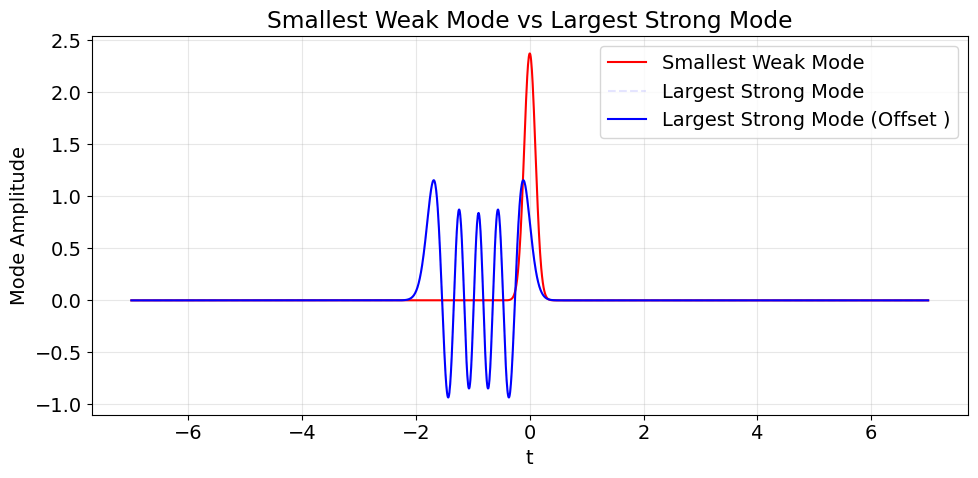

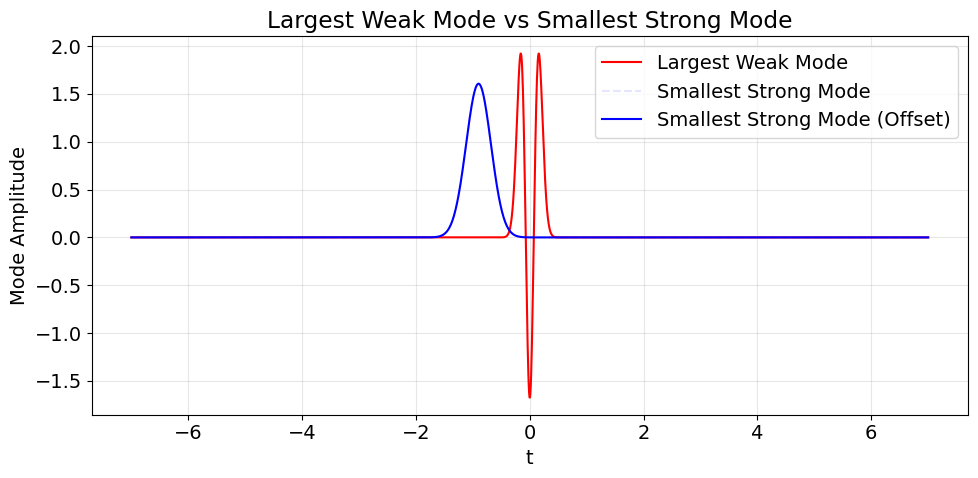

In [7]:
smallest_weak_mode = hg_basis_1[0]
largest_strong_mode = hg_basis_2[-1]


fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t.cpu(), smallest_weak_mode.cpu().numpy(), color='red', label='Smallest Weak Mode')
ax.plot(t.cpu(), largest_strong_mode.cpu().numpy(), color='blue', linestyle='--', alpha=0.1, label='Largest Strong Mode')
ax.plot(t.cpu(), largest_strong_mode.cpu().numpy(), color='b', label='Largest Strong Mode (Offset )')

ax.set_xlabel("t")
ax.set_ylabel("Mode Amplitude")
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.title("Smallest Weak Mode vs Largest Strong Mode")
plt.tight_layout()
plt.show()

# Plot largest weak mode and smallest strong mode, with offset for strong as above

largest_weak_mode = hg_basis_1[-1]
smallest_strong_mode = hg_basis_2[0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t.cpu(), largest_weak_mode.cpu().numpy(), color='r', label='Largest Weak Mode')
ax.plot(t.cpu(), smallest_strong_mode.cpu().numpy(), color='b', linestyle='--', alpha=0.1, label='Smallest Strong Mode')
ax.plot(t.cpu(), smallest_strong_mode.cpu().numpy(), color='b', label='Smallest Strong Mode (Offset)')

ax.set_xlabel("t")
ax.set_ylabel("Mode Amplitude")
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.title("Largest Weak Mode vs Smallest Strong Mode")
plt.tight_layout()
plt.show()


